Experiment 10: Model Evaluation and Deployment for Real-World
Applications
In this experiment, students will evaluate the performance of a deep learning
model on test data and deploy it using Flask or FastAPI for real-time predictions

experiment10\
│\
├── train.py        # Train + evaluate + save model\
├── app.py          # FastAPI deployment\
└── model.h5        # Saved model (generated)\

In [ ]:
pip install fastapi uvicorn

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8951 - loss: 0.3570 - val_accuracy: 0.9535 - val_loss: 0.1632
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9467 - loss: 0.1806 - val_accuracy: 0.9670 - val_loss: 0.1157
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9578 - loss: 0.1385 - val_accuracy: 0.9679 - val_loss: 0.1068
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9646 - loss: 0.1170 - val_accuracy: 0.9712 - val_loss: 0.0951
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9694 - loss: 0.0991 - val_accuracy: 0.9737 - val_loss: 0.0888
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9757 - loss: 0.0845

Test Accuracy: 0.9757000207901001
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1      

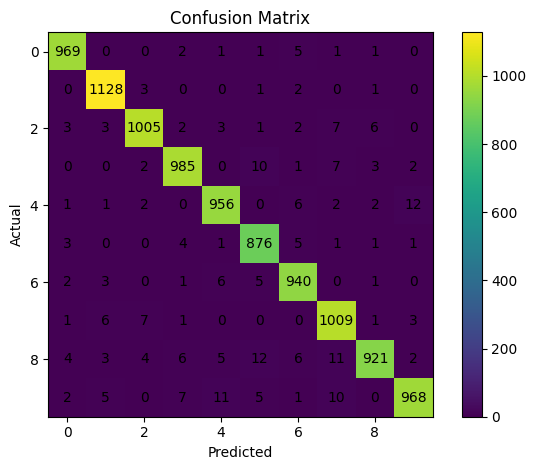

ValueError: The filename must end in `.weights.h5`. Received: filepath=weights.h5

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# 📊 Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# 🏗️ Build model
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),   # ✅ modern way
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🚀 Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2
)

# 📊 Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("\nTest Accuracy:", acc)

# 🔍 Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# 📄 Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

# 🔥 Confusion Matrix (Improved visualization)
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

# Annotate values (better for viva)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

# 💾 SAVE MODEL (🔥 FIXED)
model.save("model.keras")   # ✅ use new format
model.save_weights("weights.h5")

print("\nModel saved as model.keras")

In [ ]:
!pip install fastapi uvicorn pyngrok scikit-learn joblib

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "model.pkl")

['model.pkl']

In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      1.00      0.94         8
           2       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
import joblib

# Load model
model = joblib.load("model.pkl")

app = FastAPI()

# ✅ Define input schema
class InputData(BaseModel):
    features: list

@app.get("/")
def home():
    return {"message": "Model API is running"}

@app.post("/predict")
def predict(data: InputData):
    arr = np.array(data.features).reshape(1, -1)
    prediction = model.predict(arr)
    return {"prediction": int(prediction[0])}

In [ ]:
! ngrok config add-authtoken 3D7xoUVJ9goursklkmWJEFX5GiM_2FwDr4RUCaQ3kzP7eT

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
import uvicorn
import threading

# Run FastAPI server in background
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

threading.Thread(target=run).start()

# Create public URL
public_url = ngrok.connect(8000)
print("Public URL:", public_url)

INFO:     Started server process [162]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Public URL: NgrokTunnel: "https://aspect-octagon-polygraph.ngrok-free.dev" -> "http://localhost:8000"


In [ ]:
import requests

url = "https://aspect-octagon-polygraph.ngrok-free.dev/predict"

data = {
    "features": [5.1, 3.5, 1.4, 0.2]
}

response = requests.post(url, json=data)
print(response.json())

INFO:     8.228.13.134:0 - "POST /predict HTTP/1.1" 200 OK
{'prediction': 0}


In [ ]:
!kill -9 -1